In [5]:
import pandas as pd
import matplotlib.pyplot as plt

dataset = pd.read_csv('dataset.csv')
dataset.head()

,filepath,patient_name,birth_year,xray_type,datetime,norm_name,datetime_obj,date_only,match_score,match_status,...,ketqua_Doctor,ketqua_Technician,ketqua_Date assign,ketqua_Date start,ketqua_Date end,ketqua_Result,ketqua_norm_name,ketqua_date_start_obj,ketqua_date_only,ketqua_calc_birth_year
0,../XQUANG\20240226\20240226013\20240226013_202...,MA THI NGUYET,1973.0,SPINE,2024-02-26 08:47:23,MA THI NGUYET,2024-02-26 08:47:23,2024-02-26,1.200000,Matched,...,Vũ Văn Chung,Võ Ngọc Thạch,26/02/2024 08:43,26/02/2024 09:05,26/02/2024 09:06,HÌNH ẢNH THOÁI HÓA XƯƠNG CỘT SỐNG CỔ,MA THI NGUYET,2024-02-26 09:05:00,2024-02-26,1973.0
1,../XQUANG\20240226\20240226013\20240226013_202...,MA THI NGUYET,1973.0,SPINE,2024-02-26 08:47:52,MA THI NGUYET,2024-02-26 08:47:52,2024-02-26,1.200000,Matched,...,Vũ Văn Chung,Võ Ngọc Thạch,26/02/2024 08:43,26/02/2024 09:05,26/02/2024 09:06,HÌNH ẢNH THOÁI HÓA XƯƠNG CỘT SỐNG CỔ,MA THI NGUYET,2024-02-26 09:05:00,2024-02-26,1973.0
2,../XQUANG\20240226\20240226013\20240226013_202...,MA THI NGUYET,1973.0,SPINE,2024-02-26 08:48:13,MA THI NGUYET,2024-02-26 08:48:13,2024-02-26,1.200000,Matched,...,Vũ Văn Chung,Võ Ngọc Thạch,26/02/2024 08:43,26/02/2024 09:05,26/02/2024 09:06,HÌNH ẢNH THOÁI HÓA XƯƠNG CỘT SỐNG CỔ,MA THI NGUYET,2024-02-26 09:05:00,2024-02-26,1973.0
3,../XQUANG\20240226\20240226014\20240226014_202...,NGUYEN DANG TUAN,1954.0,CHEST,2024-02-26 09:10:10,NGUYEN DANG TUAN,2024-02-26 09:10:10,2024-02-26,1.167742,Matched,...,Vũ Văn Chung,Võ Ngọc Thạch,26/02/2024 09:06,26/02/2024 09:11,26/02/2024 09:12,- HUYẾT PHẾ QUẢN HAI BÊN TĂNG ĐẬM\r\n- BÓNG TI...,NGUYEN ANG TUAN,2024-02-26 09:11:00,2024-02-26,1954.0
4,../XQUANG\20240226\20240226015\20240226015_202...,NGUYEN QUE,1946.0,SKULL,2024-02-26 09:15:43,NGUYEN QUE,2024-02-26 09:15:43,2024-02-26,1.033333,Matched,...,Vũ Văn Chung,Võ Ngọc Thạch,26/02/2024 09:11,26/02/2024 09:18,26/02/2024 09:20,- KHÔNG THẤY HÌNH ẢNH TỔN THƯƠNG XƯƠNG HỘP SỌ ...,NGUYEN THI QUE,2024-02-26 09:18:00,2024-02-26,1946.0


In [3]:
# Print all column names
print(dataset.columns.tolist())

['filepath', 'patient_name', 'birth_year', 'xray_type', 'datetime', 'norm_name', 'datetime_obj', 'date_only', 'match_score', 'match_status', 'ketqua_STT', 'ketqua_ID', 'ketqua_Name', 'ketqua_Female', 'ketqua_Male', 'ketqua_Address', 'ketqua_Insurance', 'ketqua_Diagnose', 'ketqua_Department', 'ketqua_Require', 'ketqua_Film numbers', 'ketqua_Doctor', 'ketqua_Technician', 'ketqua_Date assign', 'ketqua_Date start', 'ketqua_Date end', 'ketqua_Result', 'ketqua_norm_name', 'ketqua_date_start_obj', 'ketqua_date_only', 'ketqua_calc_birth_year']


In [9]:
len(dataset)

36215

Analyze dataset

xray_type
CHEST       9771
SKULL       6866
SPINE       4428
KNEE        4121
WRIST       2595
FOREARM     1615
FOOT        1534
ANKLE       1221
HAND        1158
SHOULDER    1030
PELVIS       720
ELBOW        609
ABDOMEN      448
HUMERUS       94
FEMUR          5
Name: count, dtype: int64


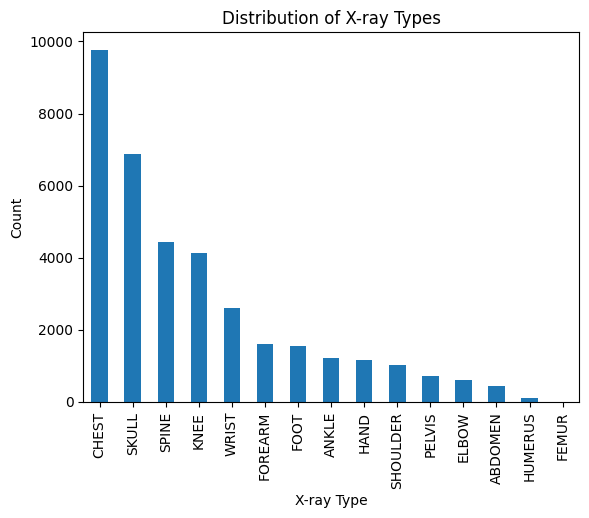

In [6]:
# Analyze data by 'xray_type' column and show chart
xray_types = dataset['xray_type'].value_counts()
print(xray_types)

xray_types.plot(kind='bar')
plt.title('Distribution of X-ray Types')
plt.xlabel('X-ray Type')
plt.ylabel('Count')
plt.show()

{'Female': np.int64(16399), 'Male': np.int64(19816)}


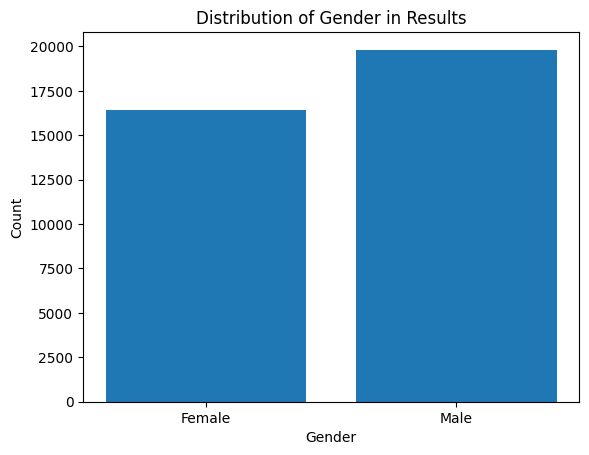

In [8]:
# Analyze data by Gender in 'ketqua_Female' and 'ketqua_Male' columns (it will contain null values) and show chart
gender_counts = {
    'Female': dataset['ketqua_Female'].notnull().sum(),
    'Male': dataset['ketqua_Male'].notnull().sum()
}
print(gender_counts)
plt.bar(gender_counts.keys(), gender_counts.values())
plt.title('Distribution of Gender in Results')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

age
6.0       11
7.0      124
8.0      222
9.0      212
10.0     261
        ... 
100.0      3
101.0      4
102.0      1
103.0      2
105.0      4
Name: count, Length: 99, dtype: int64


<Axes: xlabel='age'>

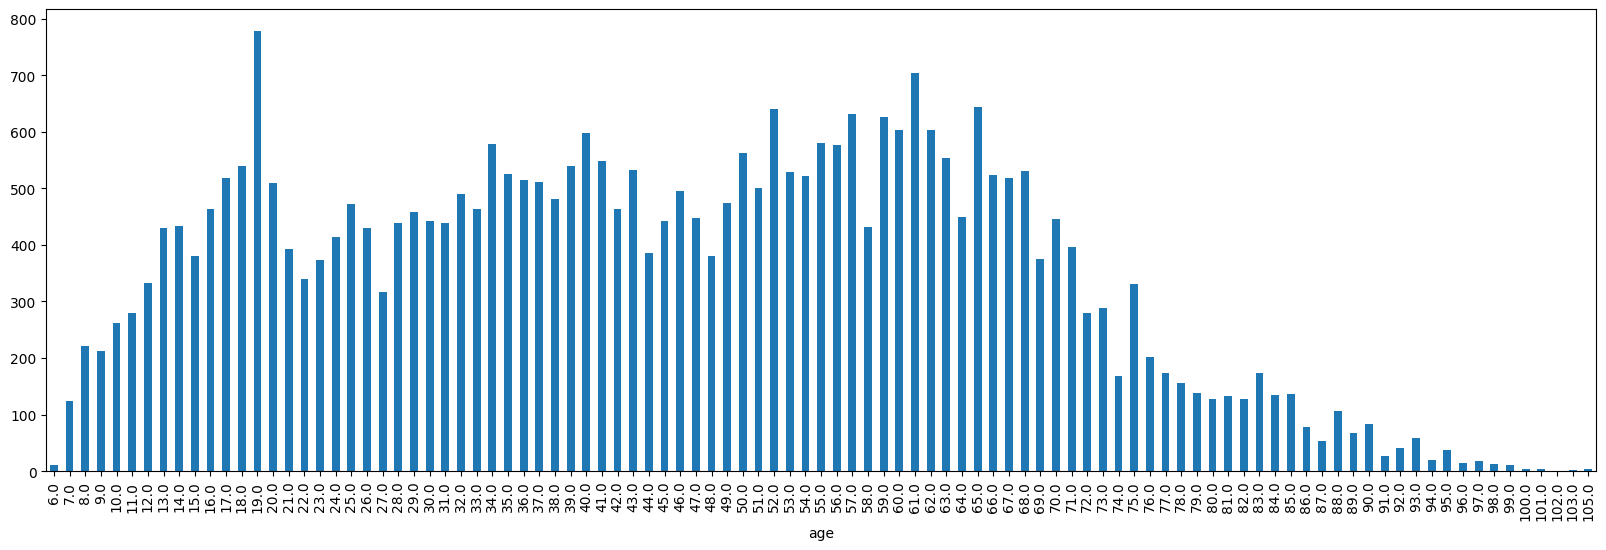

In [25]:
# Analyze data by age in 'ketqua_calc_birth_year' column and show chart (convert birth year to age)
current_year = 2025
dataset['age'] = current_year - dataset['ketqua_calc_birth_year']
age_counts = dataset['age'].value_counts().sort_index()
print(age_counts)
age_counts.plot(kind='bar', figsize=(20, 6))

ketqua_Result
- HUYẾT PHẾ QUẢN HAI BÊN TĂNG ĐẬM\r\n- BÓNG TIM TRONG GIỚI HẠN BÌNH THƯỜNG                                                                            1838
- KHÔNG THẤY HÌNH ẢNH TỔN THƯƠNG XƯƠNG HỘP SỌ DO CHẤN THƯƠNG.                                                                                         1195
- KHÔNG THẤY HÌNH ẢNH TỔN THƯƠNG XƯƠNG DO CHẤN THƯƠNG.                                                                                                1083
- HAI PHỔI SÁNG + BÓNG TIM BÌNH THƯỜNG.                                                                                                                942
HIỆN TẠI TRÊN PHIM KHÔNG THẤY HÌNH ẢNH TỔN THƯƠNG ĐIỂN HÌNH DO CHẤN THƯƠNG                                                                             813
                                                                                                                                                      ... 
- MẤT LIÊN TỤC ĐẦU NGOÀI XƯƠNG ĐÒN (P)\r\n- TRẬT KHỚP CÙ

c:\Users\Hieu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


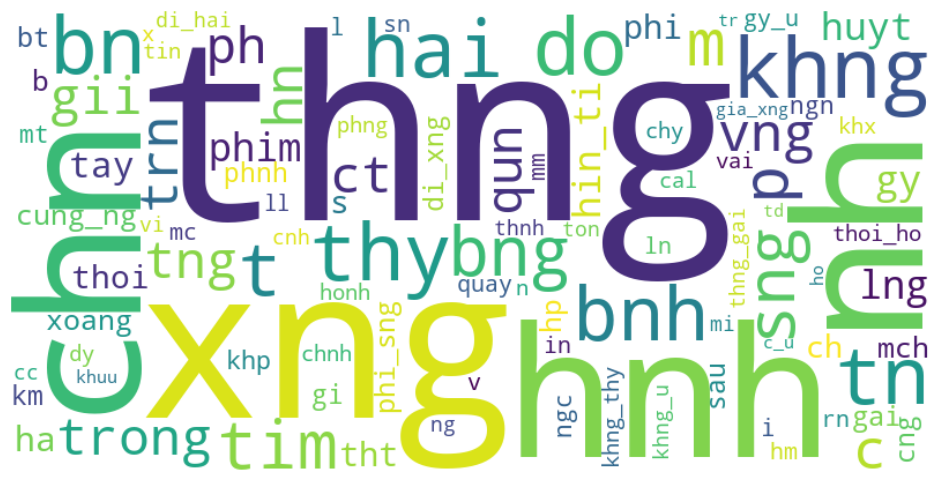

In [19]:
# Analyze data result by 'ketqua_result' column
result_counts = dataset['ketqua_Result'].value_counts()
print(result_counts)
# Show cloud word count
from wordcloud import WordCloud
import re
from collections import Counter
from underthesea import word_tokenize
string_result = " ".join(dataset["ketqua_Result"].dropna())
text = string_result.lower()
text = re.sub(r"[^a-zA-Z\s]", "", text)
words = word_tokenize(text, format="text").split()
word_freq = Counter(words)
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
)

wc.generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [26]:
# Count null values in each column
null_counts = dataset.isnull().sum()
print(null_counts)

filepath                      0
patient_name                  0
birth_year                 5437
xray_type                     0
datetime                      0
norm_name                     0
datetime_obj                  0
date_only                     0
match_score                   0
match_status                  0
ketqua_STT                    0
ketqua_ID                     0
ketqua_Name                   0
ketqua_Female             19816
ketqua_Male               16399
ketqua_Address                0
ketqua_Insurance           9829
ketqua_Diagnose            1718
ketqua_Department             0
ketqua_Require                0
ketqua_Film numbers        1399
ketqua_Doctor                 0
ketqua_Technician             0
ketqua_Date assign            0
ketqua_Date start             0
ketqua_Date end               0
ketqua_Result               648
ketqua_norm_name            570
ketqua_date_start_obj       570
ketqua_date_only            570
ketqua_calc_birth_year     2181
age     